# Глава 2: подробные примеры и диагностические проверки

[Основная глава: длительные траектории H(d) и A(d)](../02_monthly_changes.ipynb) · [Методические пояснения](02_data_checks.md)

Здесь сохранён прежний пошаговый разбор: подготовка ноября, пример 16 ноября,
сопоставление дней и боковая проверка D3 за 22 ноября. **Нумерация разделов
2.1–2.12 и рисунков 2.1–2.11 историческая**; она относится только к этому файлу.
Для основного результата следует читать главу по ссылке выше.


## 2.1. Ноябрьские данные

Интервал **[01.11.2017, 01.12.2017)**, местное время базы. Те же датчики
**994 / 1010 / 1026**; по **10 582 записи** на каждый, всего **31 746**.
Кодов ошибки $\leq -9999$ нет. Все исходные значения, повторы и временные метки сохранены.

[Данные и происхождение](../data/ch02/README.md) · [Код и запуск](02_data_checks.md#запуск-и-следующий-шаг)

In [1]:
from pathlib import Path
import importlib
import sys
project = next(p for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "Project_description/Research_log/chapter02.py").is_file())
if str(project) not in sys.path:
    sys.path.insert(0, str(project))
from Project_description.Research_log import chapter02
# Перечитать обновлённый модуль и создать новый report в текущем ядре.
report = importlib.reload(chapter02).load_november()

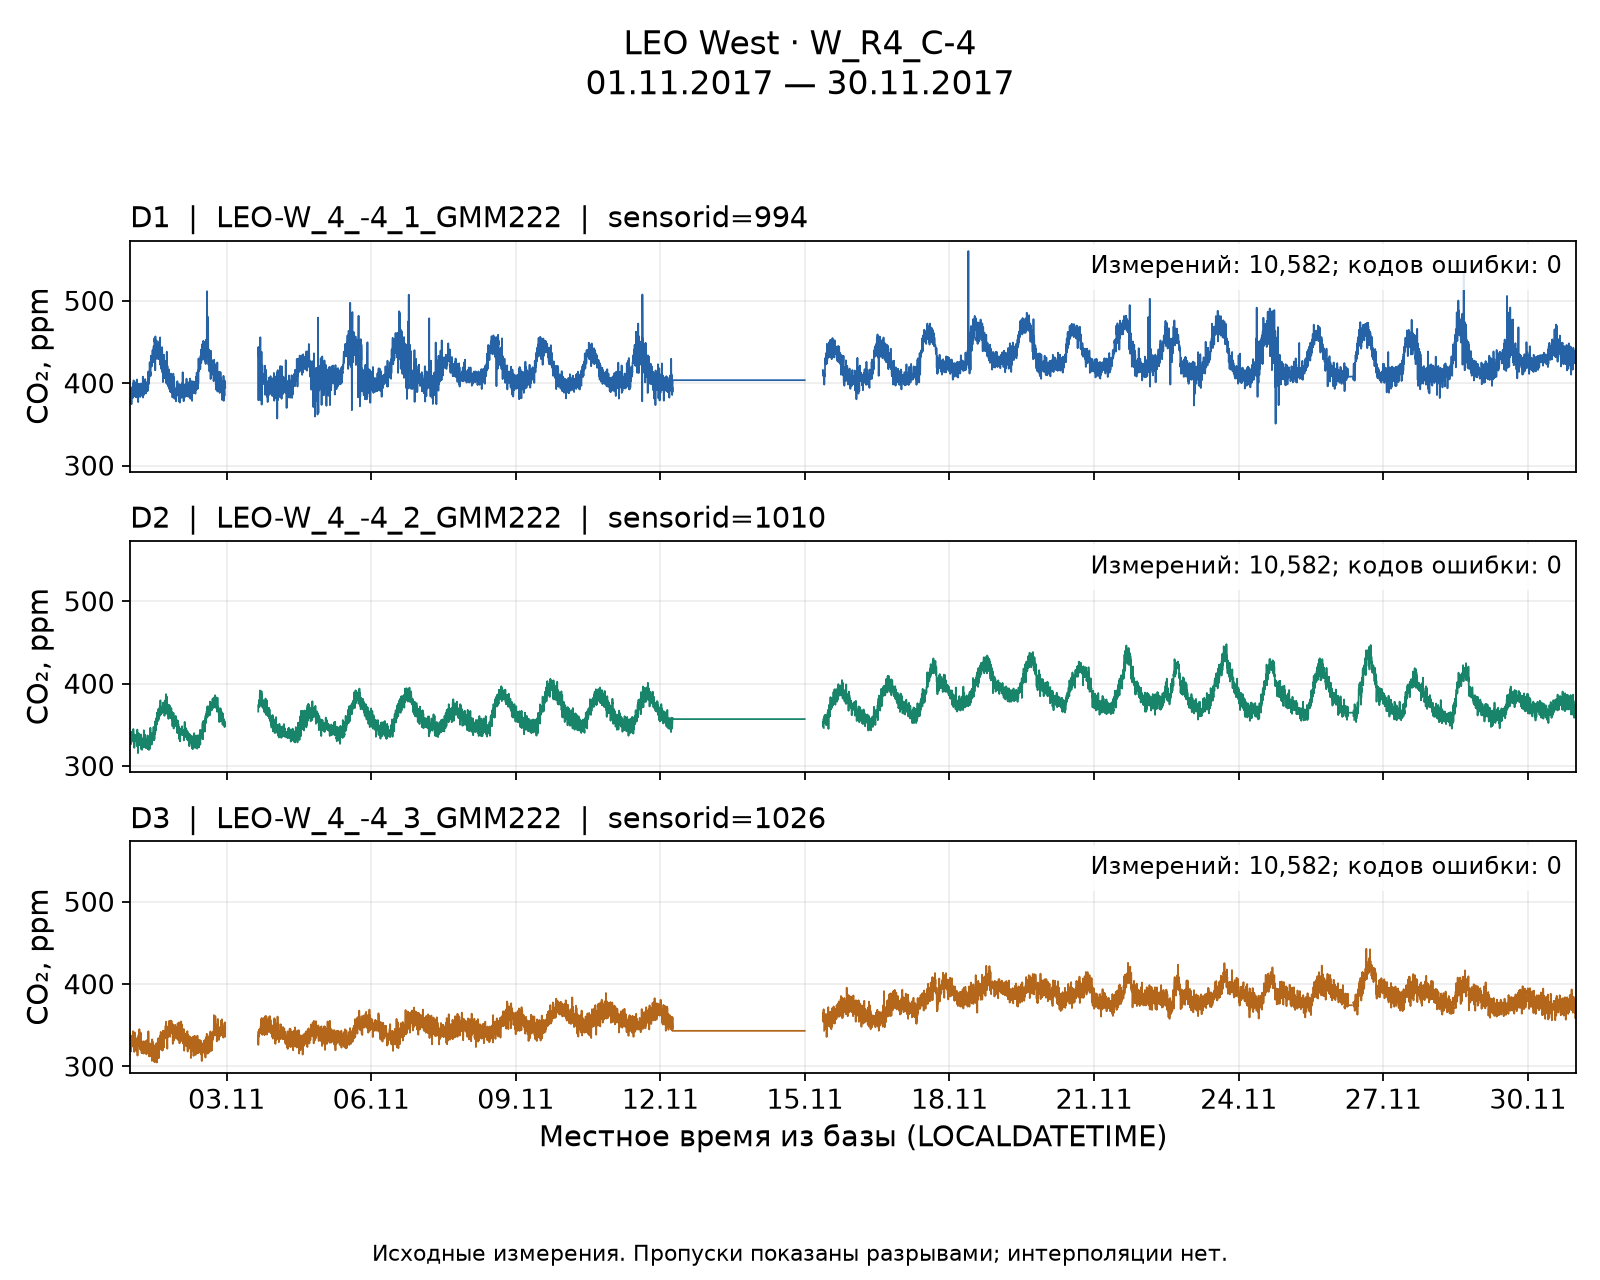

In [2]:
report.show("raw")

**Рисунок 2.1.** Три исходных ряда на общей временной шкале. Пропуски разрывают линию;
прямой участок 12–14 ноября состоит из реально записанных постоянных значений.
Интерполяция не выполнялась.

## 2.2. Неравномерное число записей

В каждом ряду есть **2262 интервала длиной 0–10 секунд** между соседними записями;
медиана положительного шага — **299 секунд**. В октябрьском снимке интервалов 0–10 секунд не было.
С 7 по 14 ноября число записей достигает 514–533 в сутки, 30 ноября — 519.
Более частые записи при одинаковых весах сильнее влияют на среднее и МНК.

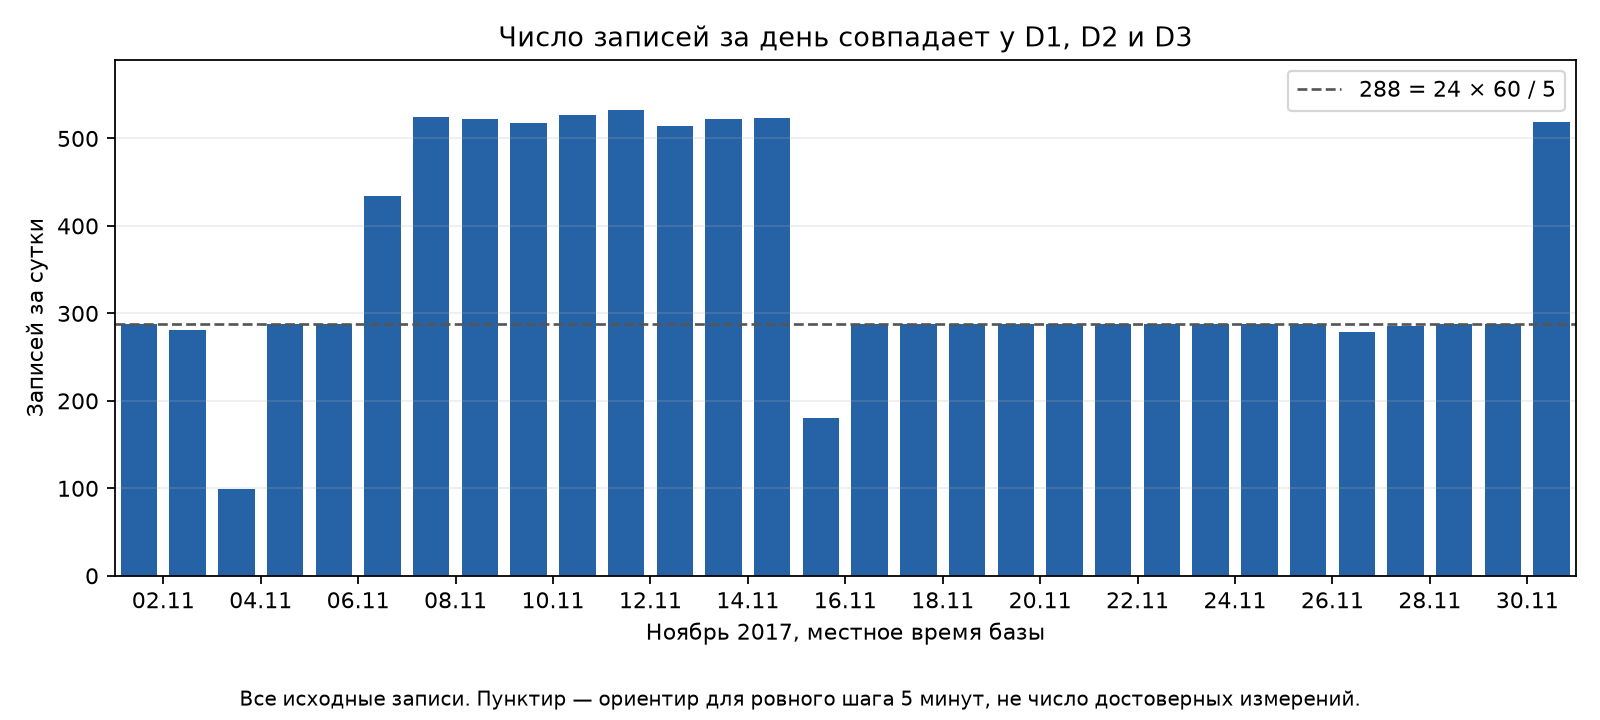

In [3]:
report.show("counts")

**Рисунок 2.2.** Суточное число записей одинаково у трёх датчиков.
Пунктир $288=24\cdot60/5$ — ориентир для равномерного шага 5 минут.
Увеличение числа строк само по себе не означает увеличение количества независимой информации.

[Подробно о шаге и пропусках](02_data_checks.md#шаг-и-число-записей)

## 2.3. Залипание датчиков

**Правило обработки:** выявленные длительные участки неизменных показаний считаю
периодами неработоспособности и исключаю из последующего анализа.

У D1/D2/D3 совпадают два таких интервала:

- **12.11.2017 06:10:04 — 14.11.2017 23:55:08:** 65,75 часа, по 1435 записей
  на датчик. Значения D1/D2/D3: **403,657 / 356,967 / 343,271 ppm**.
- **26.11.2017 06:25:05 — 26.11.2017 08:25:03:** около 2 часов,
  по 25 записей на датчик.

Каждый датчик повторяет своё значение. Исходные записи сохраняю;
в рабочих рядах на этих участках оставляю пропуски.
[Границы участков и метод обнаружения](02_data_checks.md#постоянные-участки).

> **Примечание для обсуждения с I.G.** В базе есть повторные временные метки,
> иногда с разными значениями CO₂. Способ их обработки пока не выбран.
> [Подробности](02_data_checks.md#повторные-временные-метки).

## 2.4. Результат исключения залипаний

Сопоставляю каждый исходный ряд с рабочим рядом после исключения двух интервалов.
Показываю их на одинаковых шкалах времени и концентрации.

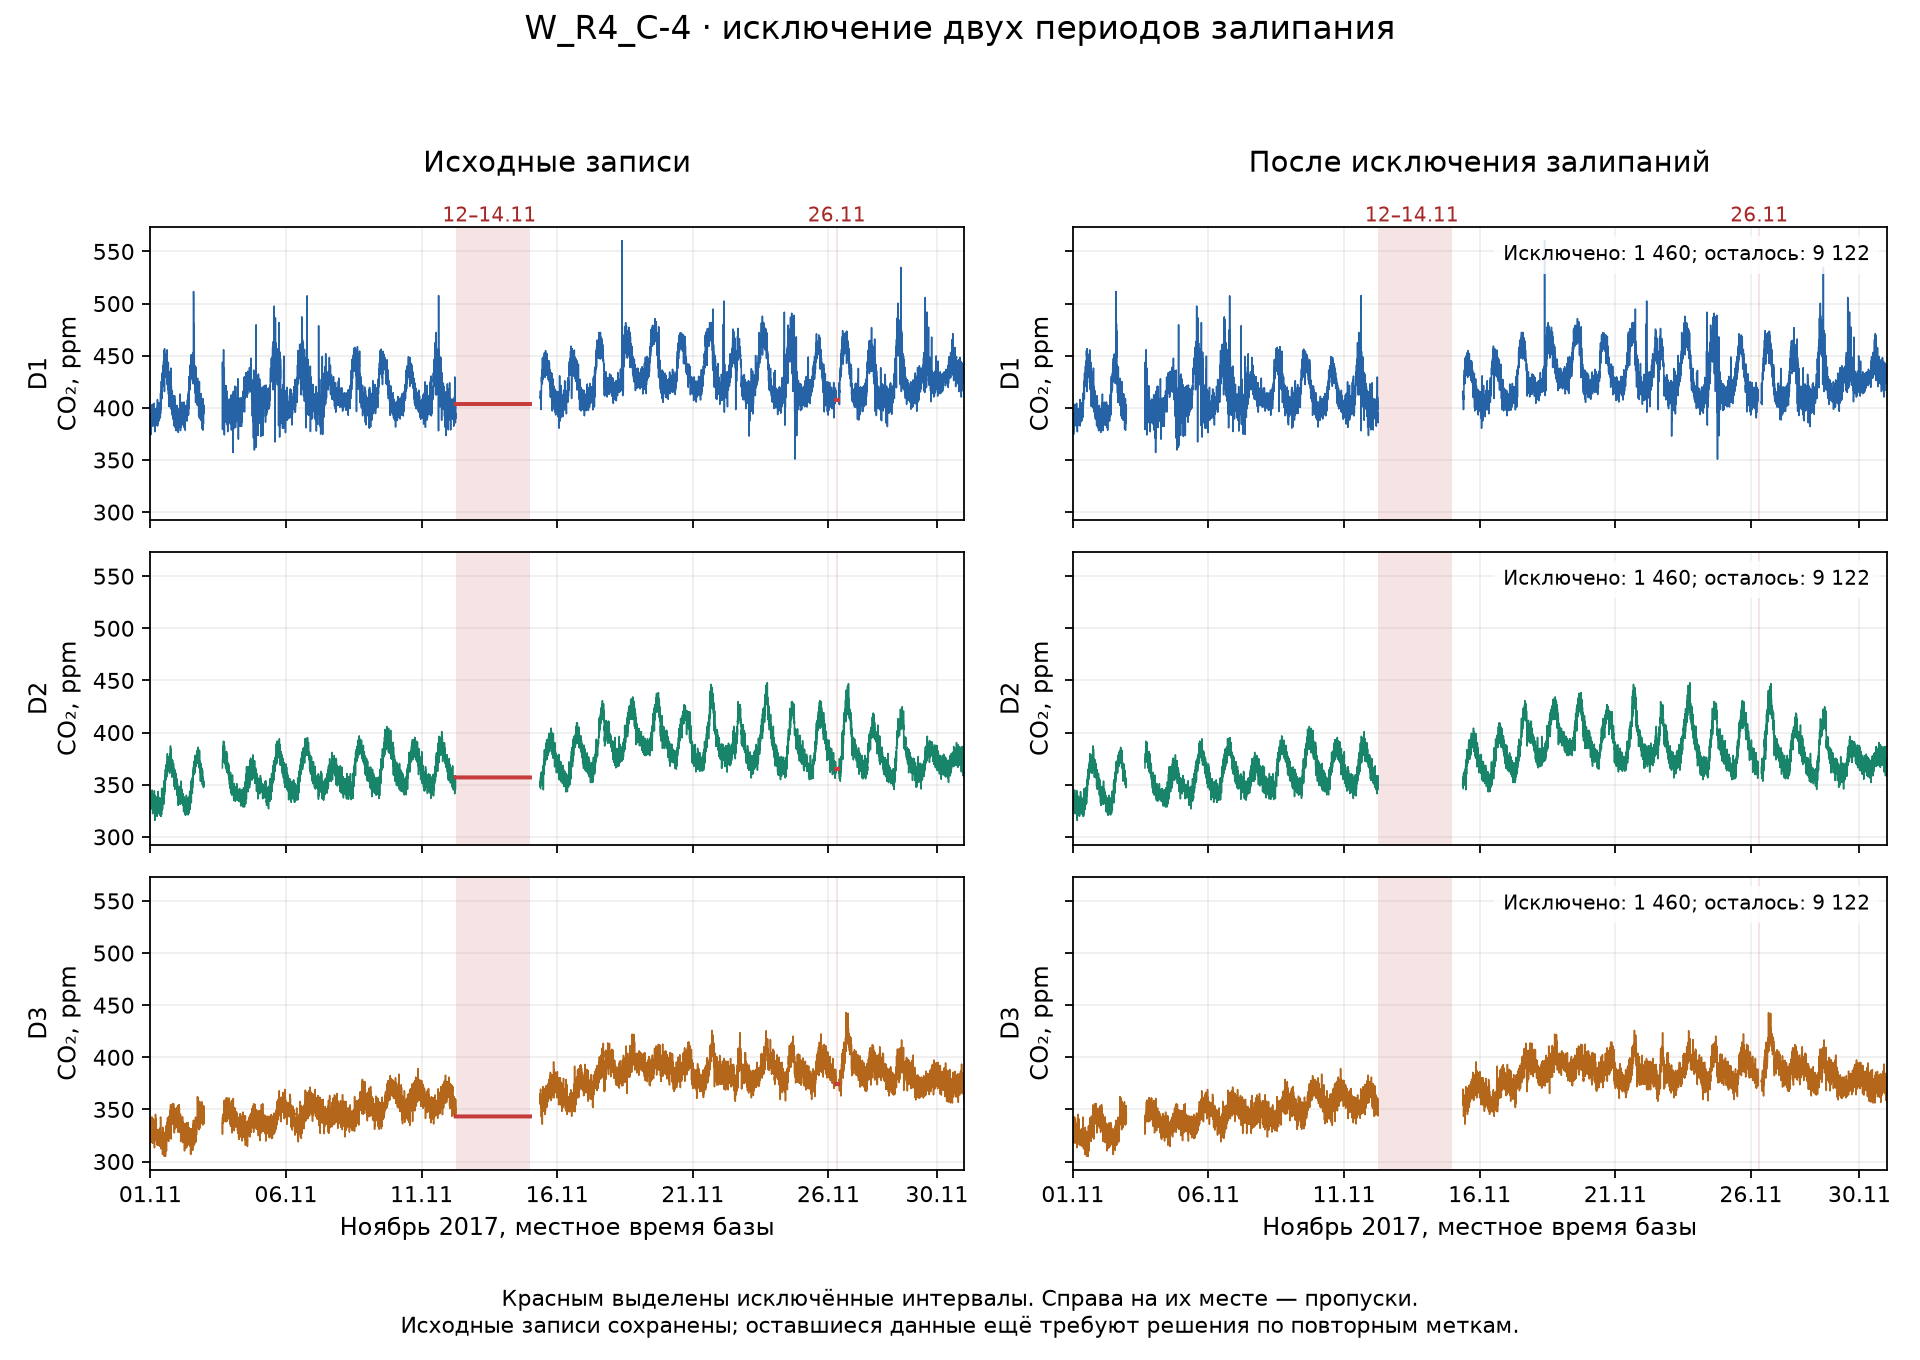

In [4]:
report.show("stuck")

**Рисунок 2.3.** Строки — D1, D2, D3. Слева — исходные записи, справа — ряды
после исключения залипаний. Красным выделены интервалы 12–14 и 26 ноября;
справа на их месте линия прерывается. Двухчасовой участок 26 ноября на масштабе
месяца выглядит как узкая полоска.

На каждом датчике исключил **1460 записей**; осталось **9122 из 10 582**.
Исключённые значения не заменяю нулями и не восстанавливаю интерполяцией.
Все остальные записи сохранены, включая повторы, для которых правило ещё предстоит выбрать.

## 2.5. Для каких суток хватает данных

Проверяю полные сутки одновременно у D1, D2 и D3. Для прежнего суточного среднего
нужны данные в окне $[t-12\,\mathrm{h},\ t+12\,\mathrm{h})$ вокруг каждого момента $t$.
Поэтому отдельно отмечаю наличие самих записей и наличие полного окружающего окна.

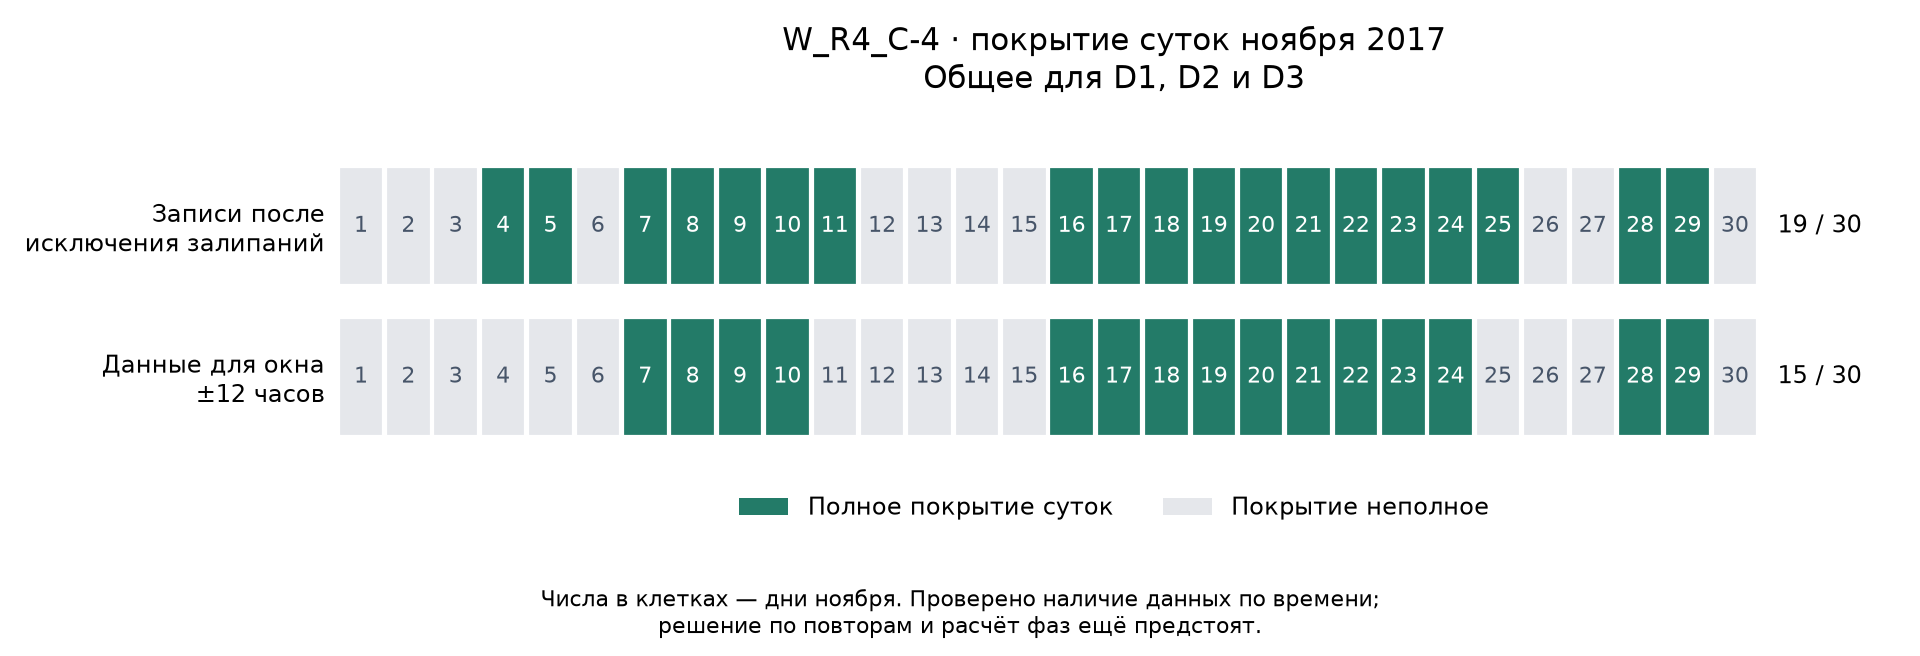

In [5]:
report.show("coverage")

**Рисунок 2.4.** Числа — дни ноября. Зелёным отмечены сутки с полным покрытием
по времени у всех трёх датчиков, серым — с неполным.
Верхняя строка проверяет оставшиеся записи: **19 суток**.
Нижняя учитывает ещё окно ±12 часов: **15 суток — 7–10, 16–24, 28–29 ноября**.

Например, **11 ноября** записи есть весь день, но для позднего вечера уже не хватает
следующих 12 часов из-за залипания 12 ноября. Поэтому сверху клетка зелёная,
а снизу серая. Серый цвет не означает неработоспособность датчика весь день.

**Получено на этом шаге:** 15 суток с полным покрытием по времени для прежней
обработки. Отдельный пример 16 ноября рассматриваю ниже.

[Подробно о календаре](02_data_checks.md#day-coverage)

## 2.6. Один день: среднее и отклонения

**Выбор дня:** 16 ноября — произвольно выбранный начальный пример среди дней
с полными суточными данными и окружающим окном ±12 часов. Представительность
для ноября не предполагается. [Подробнее о выборе](02_data_checks.md#why-november-16).

Беру **16 ноября**, по **288 показаний D1/D2/D3**. Для среднего в окне ±12 часов
использую окружающие данные 15–17 ноября; в этом контексте повторных меток нет.
Из каждого показания вычитаю его окружающее среднее:

$$
r_j(t)=C_j(t)-m_j(t),\qquad j\in\{D1,D2,D3\}.
$$

Здесь $m_j(t)$ — среднее за 24 часа вокруг момента $t$.

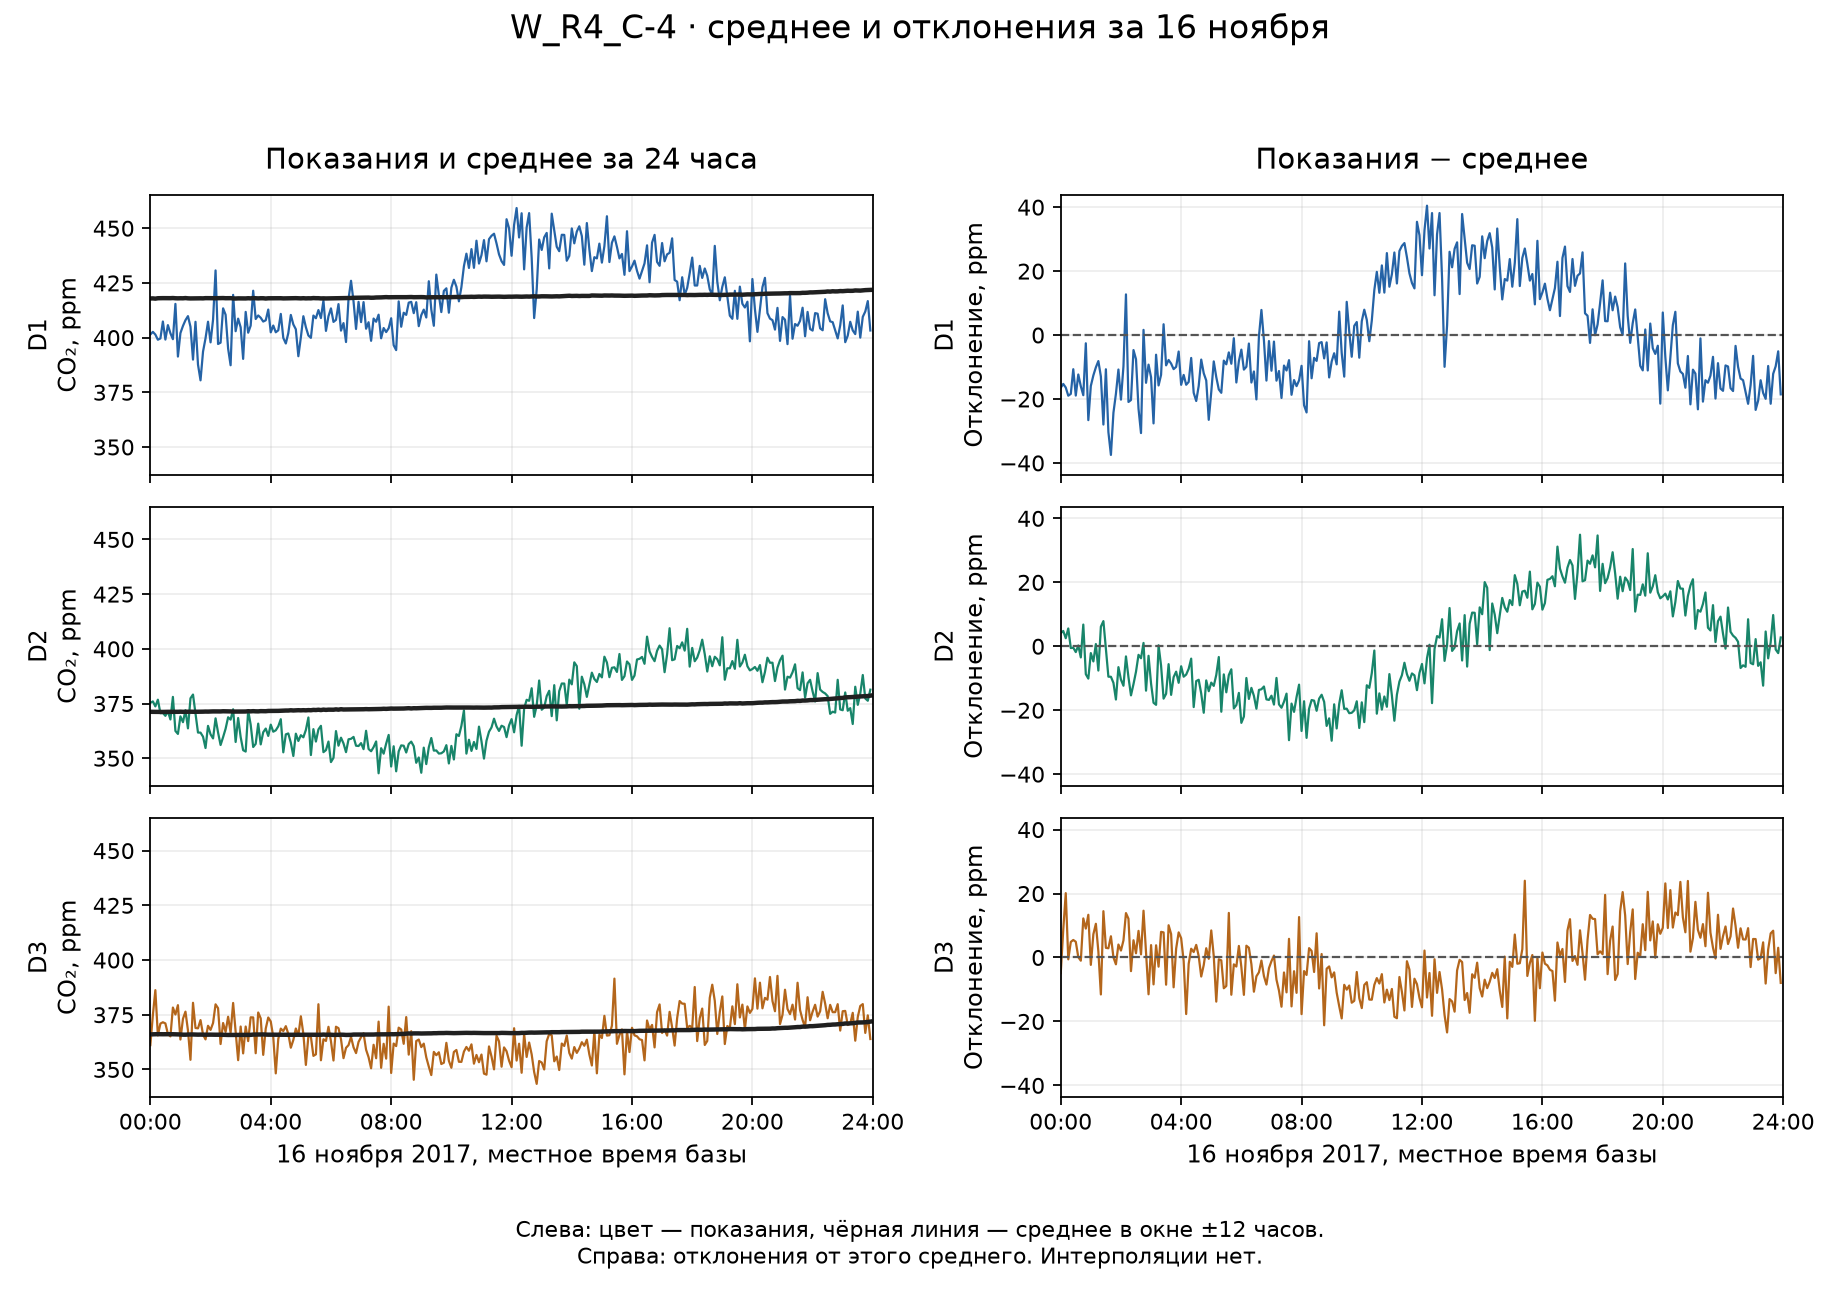

In [6]:
report.show("example_trend")

**Рисунок 2.5.** Строки — D1, D2, D3. Слева цветом показаны исходные концентрации,
чёрным — среднее в окне ±12 часов. Справа — отклонения от этого среднего;
пунктир соответствует нулю. Шкалы одинаковы внутри каждого столбца.

**Получено:** среднее и отклонения для всех **288 точек каждого датчика**, всего
**864 точки**. Теперь сравниваю изменения относительно собственного среднего уровня
каждого датчика. В остатках видны различия формы и положения подъёмов;
быстрые колебания сохранены.

[Подробности подготовки](02_data_checks.md#november-16-trend)

## 2.7. Суточная модель одного дня

К тем же **288 отклонениям каждого датчика за 16 ноября** подбираю одну гармонику
с заранее заданным периодом 24 часа:

$$
\widehat r_j(t)=c_j+A_j\cos\left[\frac{2\pi}{24}\bigl(h(t)-h_{\max,j}\bigr)\right].
$$

Здесь $h(t)$ — местное время суток в часах, $A_j$ — амплитуда,
$h_{\max,j}$ — время максимума модели. Использую тот же МНК, что и в главе 1.

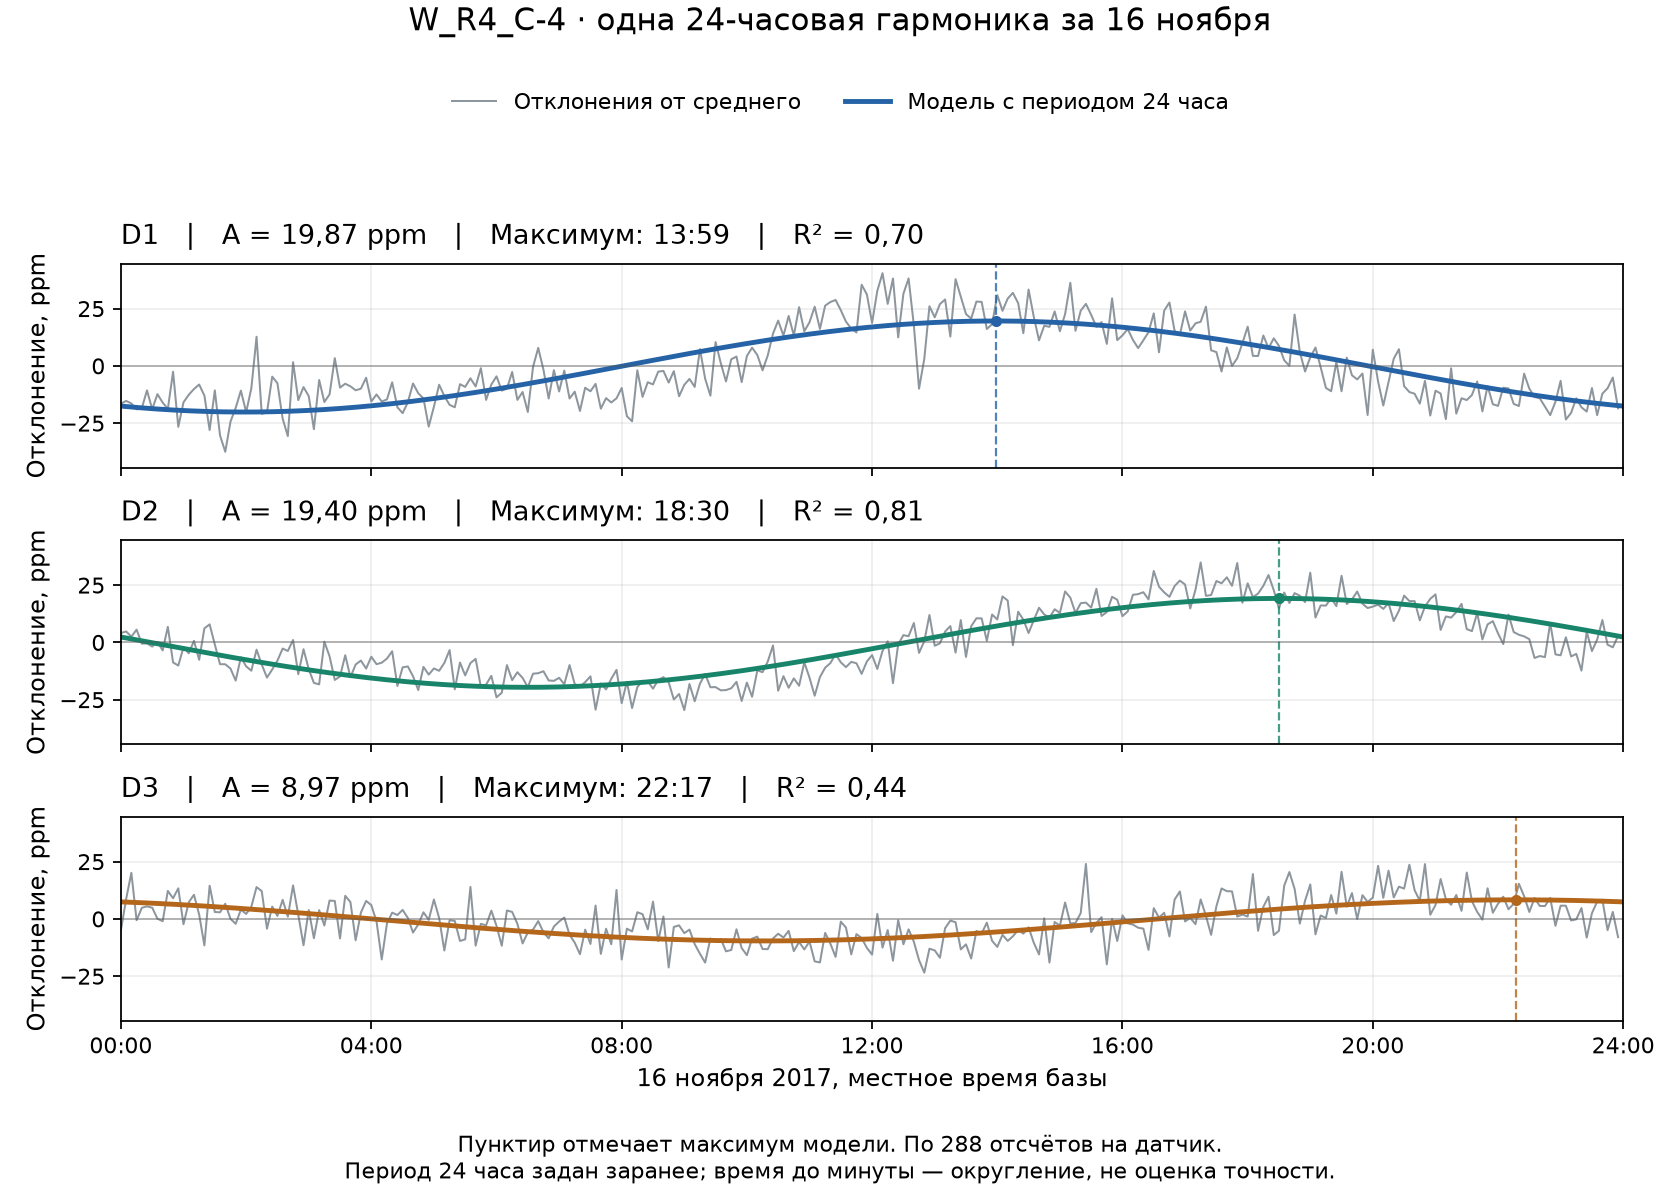

In [7]:
report.show("example_diurnal")

**Рисунок 2.6.** Серым показаны отклонения, цветом — подобранная модель;
вертикальным пунктиром — её максимум. Все три панели имеют одинаковые шкалы.
Подписи времени округлены до минуты и не означают минутную точность оценки.

**Получено:** модельные максимумы D1/D2/D3 — **13:59 / 18:30 / 22:17**,
амплитуды — **19,87 / 19,40 / 8,97 ppm**, R² — **0,70 / 0,81 / 0,44**.
D3 слабее описывается одной гармоникой: около 56% разброса остаётся вне модели.
Это результат одного дня, без оценки устойчивости в течение ноября.

[Подробности модели и R²](02_data_checks.md#november-16-harmonic)

## 2.8. Сдвиги между максимумами

Для тех же моделей **16 ноября** вычитаю время максимума первого датчика
из времени максимума второго. Как в главе 1, выбираю сдвиг на ветви $[-12,12)$ часов:

$$
\Delta_{jk}=\mathrm{wrap}_{24}(h_{\max,k}-h_{\max,j}).
$$

Знак **+** означает более поздний максимум второго датчика.
В этот день все три обычные разности лежат на выбранной ветви.

| Пара | Сдвиг, ч | Положение второго максимума |
|---|---:|---|
| D1 → D2 | +4,53 | D2 позже D1 |
| D2 → D3 | +3,77 | D3 позже D2 |
| D1 → D3 | +8,30 | D3 позже D1 |

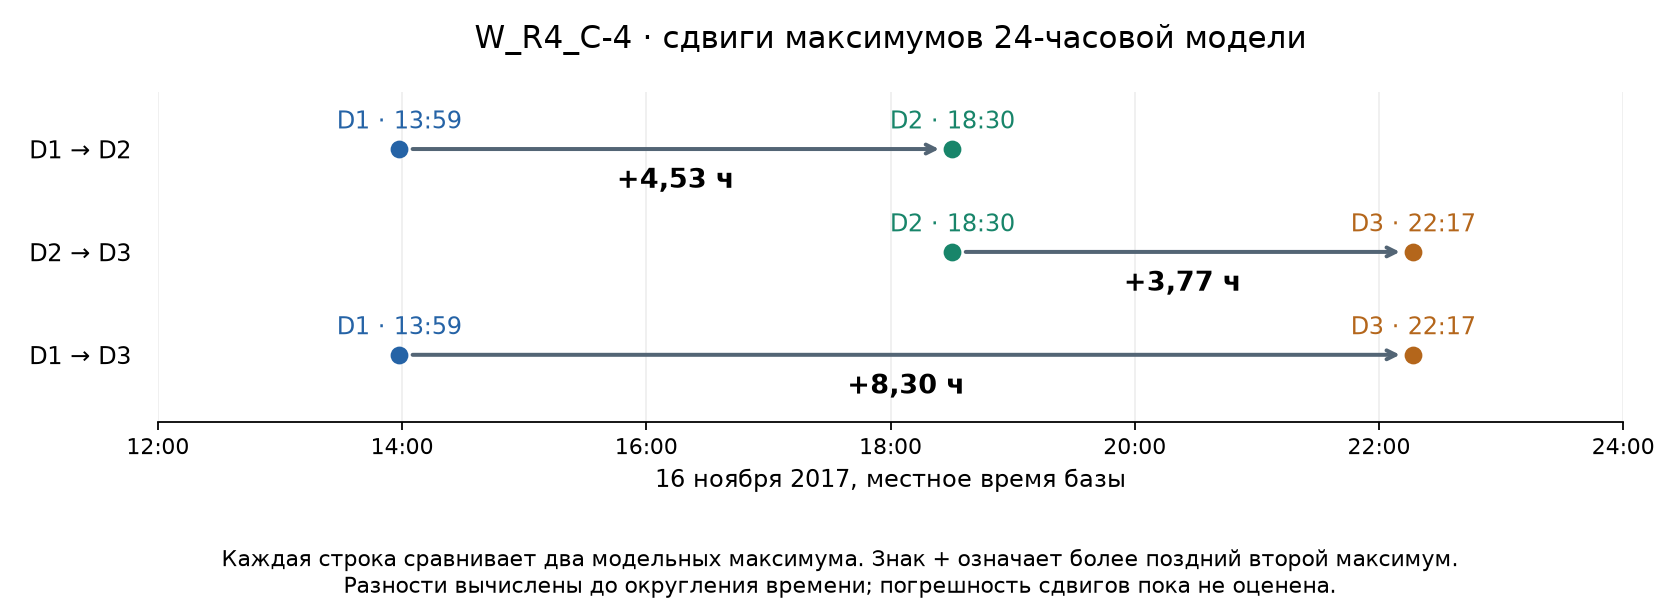

In [8]:
report.show("example_lags")

**Рисунок 2.7.** Точки — максимумы моделей из рисунка 2.6; стрелки показывают
их взаимное положение на общей шкале времени. Разности рассчитаны до округления
времён, приведённых в подписях.

**Получено:** за 16 ноября порядок модельных максимумов — D1, затем D2, затем D3.
Это **сдвиги суточных волн**, а не измеренное время переноса CO₂. Погрешность
сдвигов и их устойчивость по дням ещё не оценены; для D3 сохраняется R² ≈ 0,44.

[Знак, округление и смысл сдвигов](02_data_checks.md#november-16-lags)

## 2.9. Сопоставление двух соседних дней

Повторяю тот же расчёт для **17 ноября**: по 288 показаний на датчик,
контекст для среднего — 16–18 ноября, без повторных меток и неполных окон.
Сравниваю с 16 ноября: отдельные суточные подгонки, одинаковый период 24 часа.

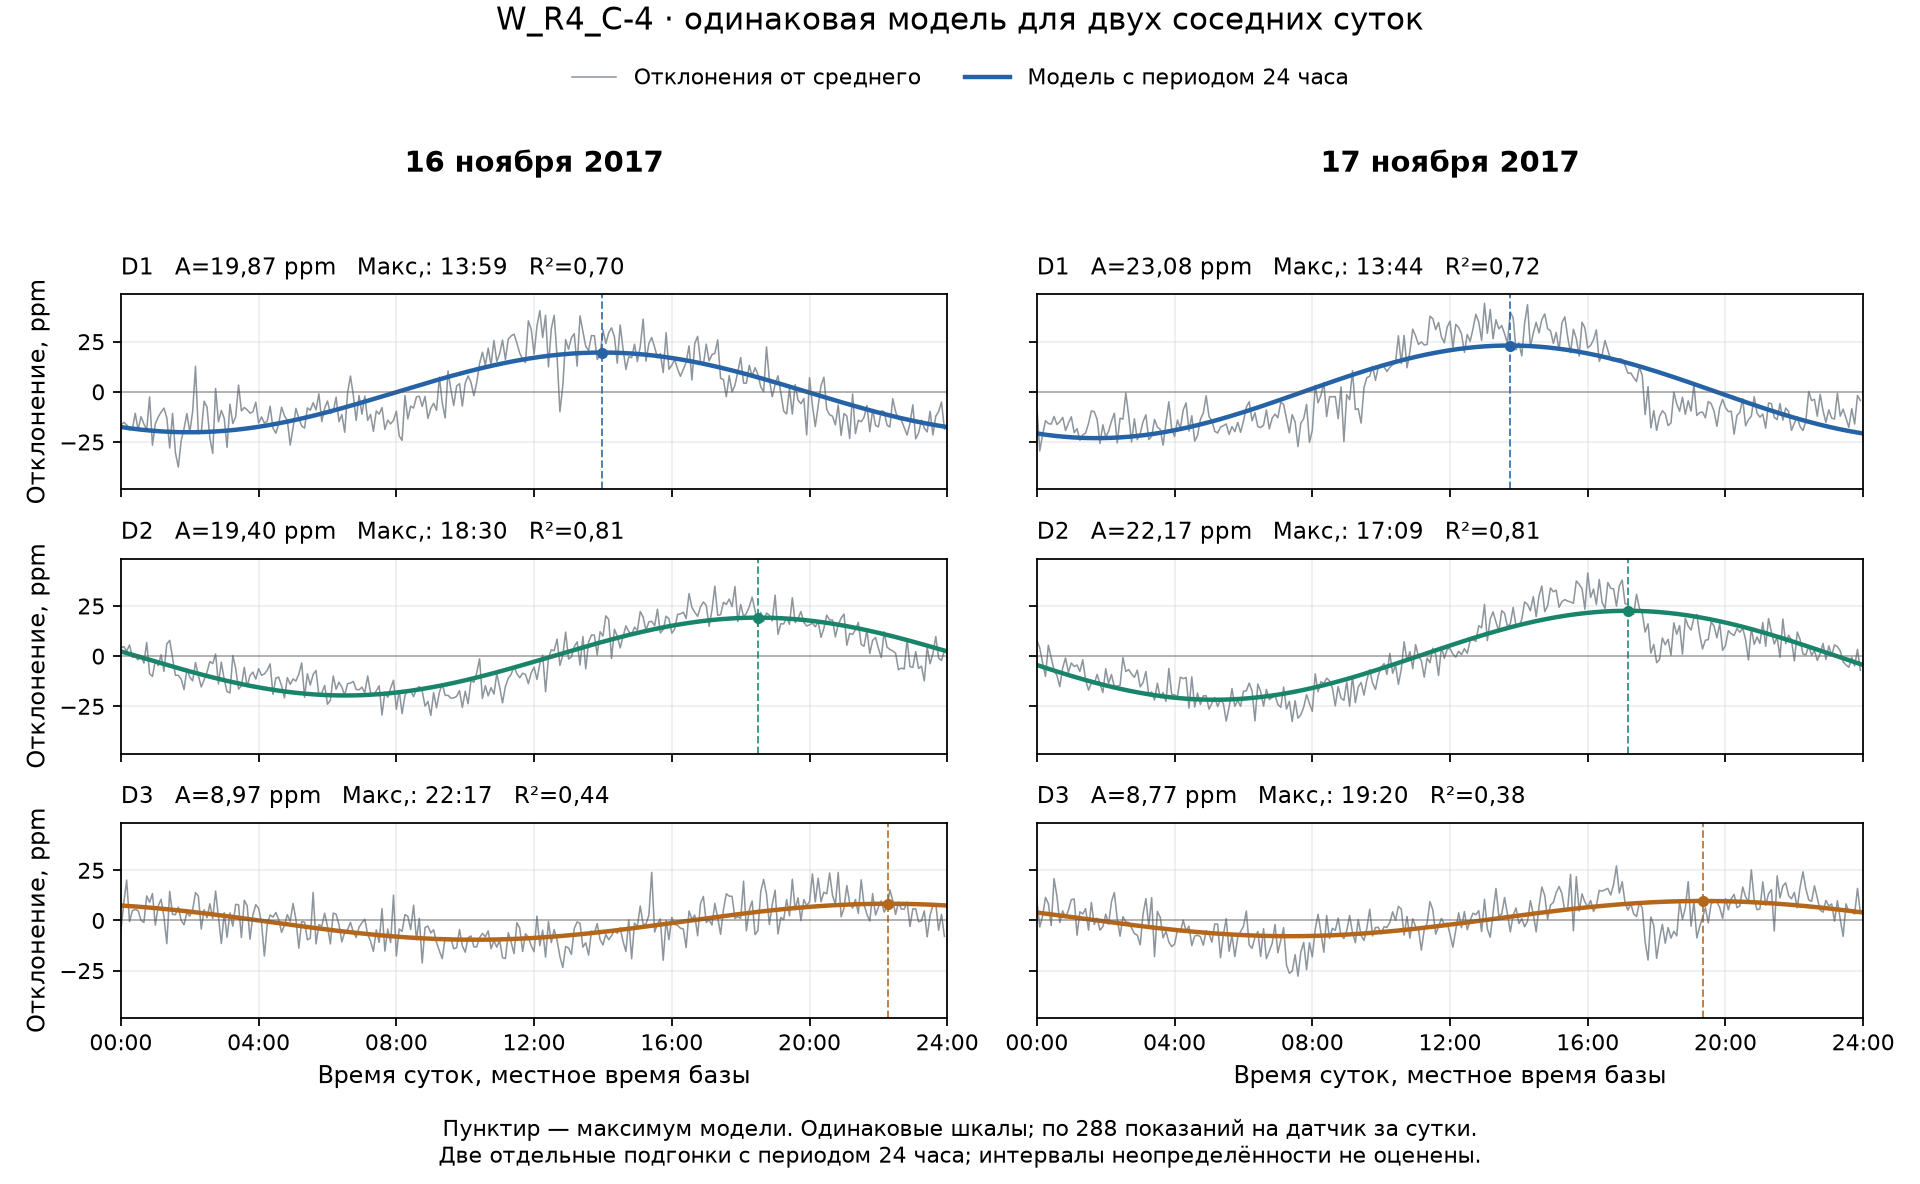

In [9]:
report.show("two_days")

**Рисунок 2.8.** Слева 16 ноября, справа 17 ноября; строки D1/D2/D3.
Серым — отклонения, цветом — модель, пунктиром — её максимум.
Все шесть панелей имеют одинаковые шкалы; амплитуды и R² подписаны над ними.
Быстрые колебания сохранены; [их периоды на этом шаге не оцениваются](02_data_checks.md#frequency-scope).

| Пара | 16 ноября, ч | 17 ноября, ч | Изменение, ч |
|---|---:|---:|---:|
| D1 → D2 | +4,53 | +3,42 | −1,11 |
| D2 → D3 | +3,77 | +2,18 | −1,59 |
| D1 → D3 | +8,30 | +5,61 | −2,70 |

**Получено:** порядок максимумов D1 → D2 → D3 сохранился; оценённые сдвиги
17 ноября меньше. R² у D3 изменился с 0,44 до 0,38. Это сравнение двух дней;
неопределённость оценок и физическая причина различий пока не установлены.

[Данные и подробности сравнения](02_data_checks.md#november-16-17)

## 2.10. Суточные изменения: 16–24 ноября

Повторяю прежний расчёт для **9 последовательных суток**. Все дни имеют
полные окна ±12 часов и по 288 показаний каждого датчика; в контекстах нет
повторных меток. Получены 27 суточных моделей по 7776 показаниям.
Период 24 часа сохранён; отбора дней по R² нет.

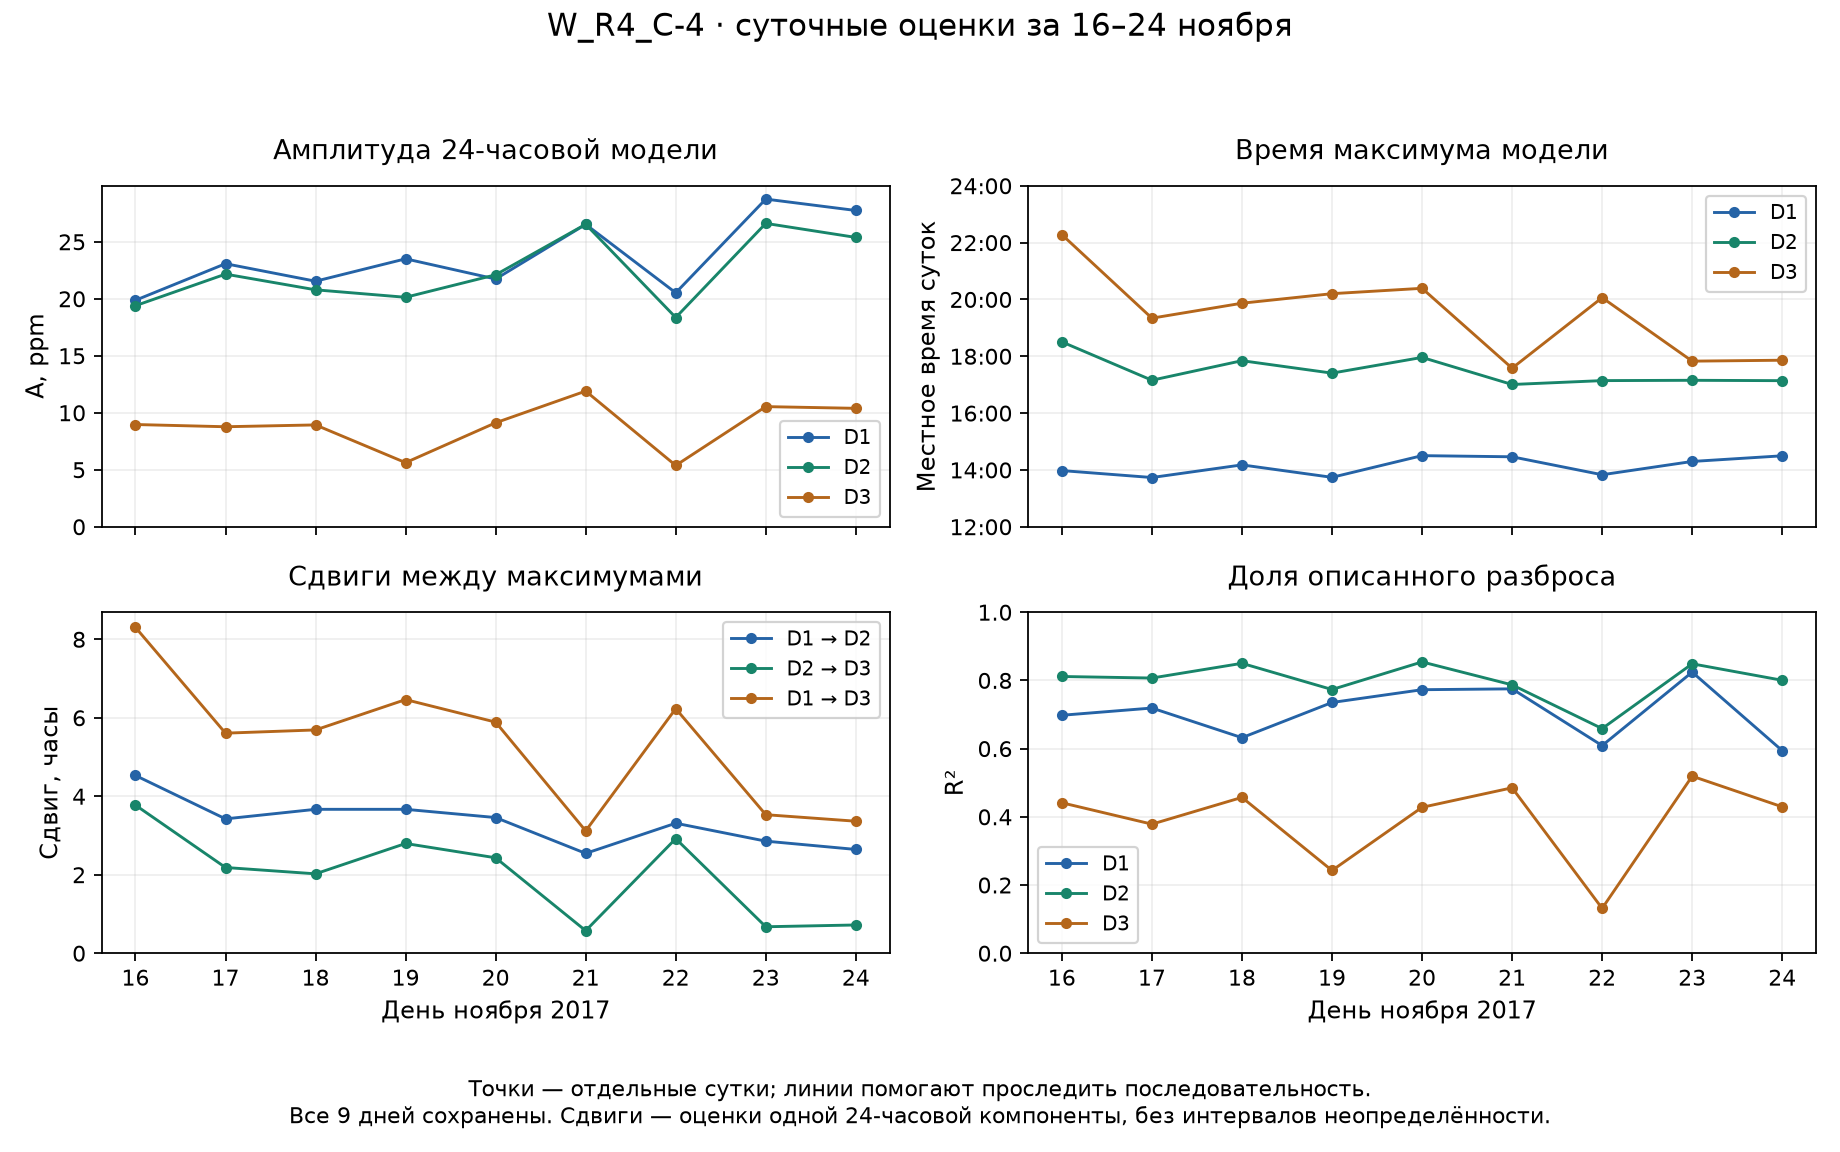

In [10]:
report.show("daily_series")

**Рисунок 2.9.** Каждая точка — отдельные сутки. Сверху: амплитуда и время
максимума; снизу: сдвиги между датчиками и R². Линии показывают последовательность оценок.

| Пара | Минимум–максимум сдвига, ч |
|---|---:|
| D1 → D2 | +2,54…+4,53 |
| D2 → D3 | +0,57…+3,77 |
| D1 → D3 | +3,12…+8,30 |

**Получено:** порядок модельных максимумов D1 → D2 → D3 совпадает на **9 из 9 суток**,
но величины сдвигов меняются. У D3 R² составляет **0,13–0,52**, минимум — 22 ноября.
Диапазоны в таблице описывают девять оценок и не являются доверительными интервалами.
Надёжность фазы D3 требует отдельной проверки.

[Данные и подробности девяти суток](02_data_checks.md#november-16-24)

## 2.11. D3: 22 ноября и соседние дни

Выбираю 22 ноября для разбора минимального R² у D3 и сопоставляю с 21 и 23 ноября.
Использую прежние подгонки и все 288 показаний каждого дня. После вычитания
среднего получено $r(t)$; теперь показываю также часть, не описанную моделью:

$$
e(t)=r(t)-\widehat r(t).
$$

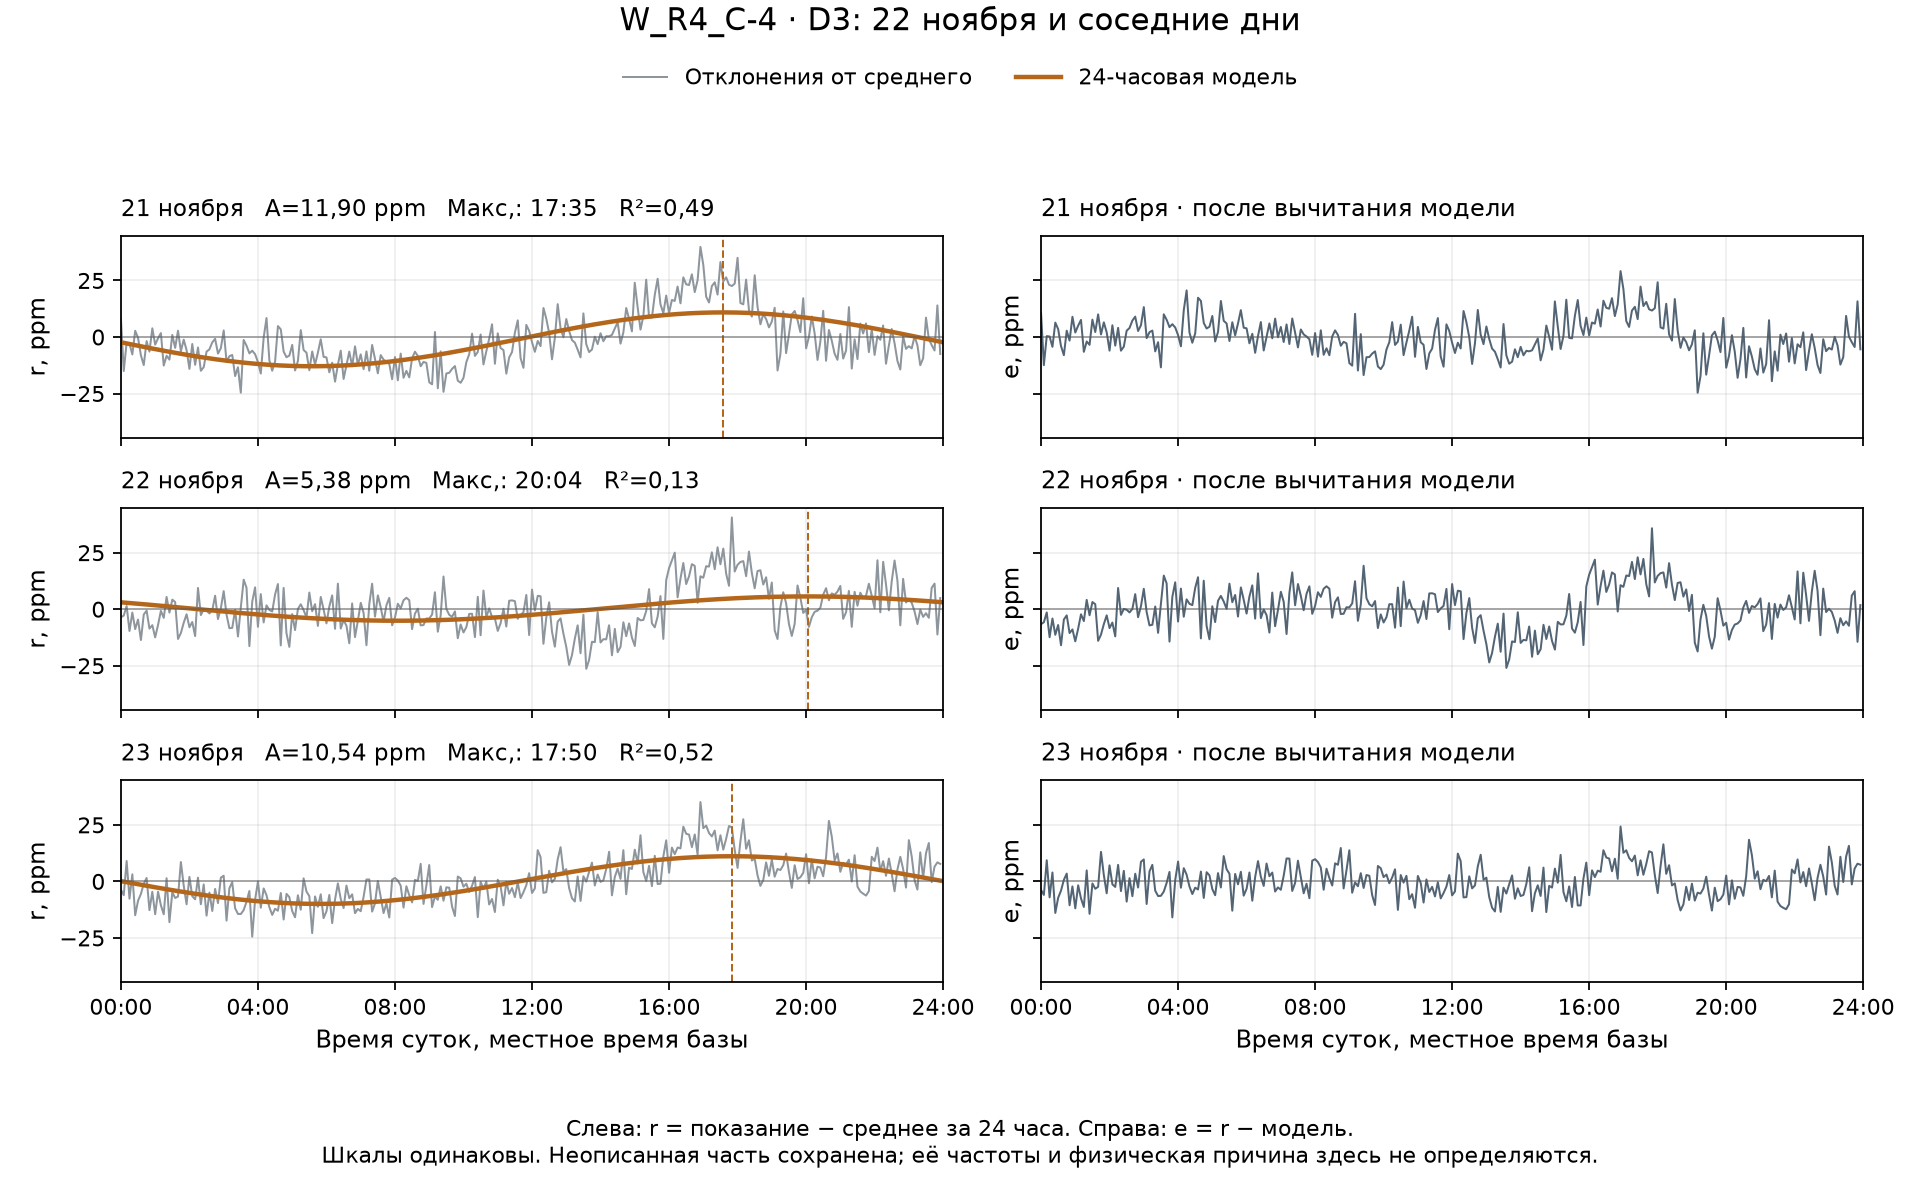

In [11]:
report.show("d3_review")

**Рисунок 2.10.** Слева — отклонения от среднего и 24-часовая модель;
справа — после вычитания модели. Строки — 21, 22, 23 ноября; все шкалы одинаковы.

| День | Амплитуда A, ppm | Максимум модели | R² |
|---|---:|---|---:|
| 21.11 | 11,90 | 17:35 | 0,49 |
| 22.11 | 5,38 | 20:04 | 0,13 |
| 23.11 | 10,54 | 17:50 | 0,52 |

**Получено:** 22 ноября суточная амплитуда примерно вдвое меньше, чем у соседних
дней. Вне модели остаются дневной спад и подъём, а также быстрые колебания.
Максимум 20:04 относится к модели; его погрешность пока не оценена.
Другие частоты и физическая причина изменений здесь не определяются.

[Подробности и размер неописанной части](02_data_checks.md#d3-november-21-23)

## 2.12. D3: чувствительность времени максимума

Для 22 ноября поочерёдно исключаю из подгонки один двухчасовой интервал:
00–02, 02–04, …, 22–24. В каждой из 12 подгонок остаётся **264 из 288 показаний**.
Прежнее среднее и период 24 часа фиксированы; исходные данные сохраняю.
Сравниваю максимум каждой подгонки с исходным 20:04:

$$
\delta h_k=\mathrm{wrap}_{24}(h_k-h_{\mathrm{full}}).
$$

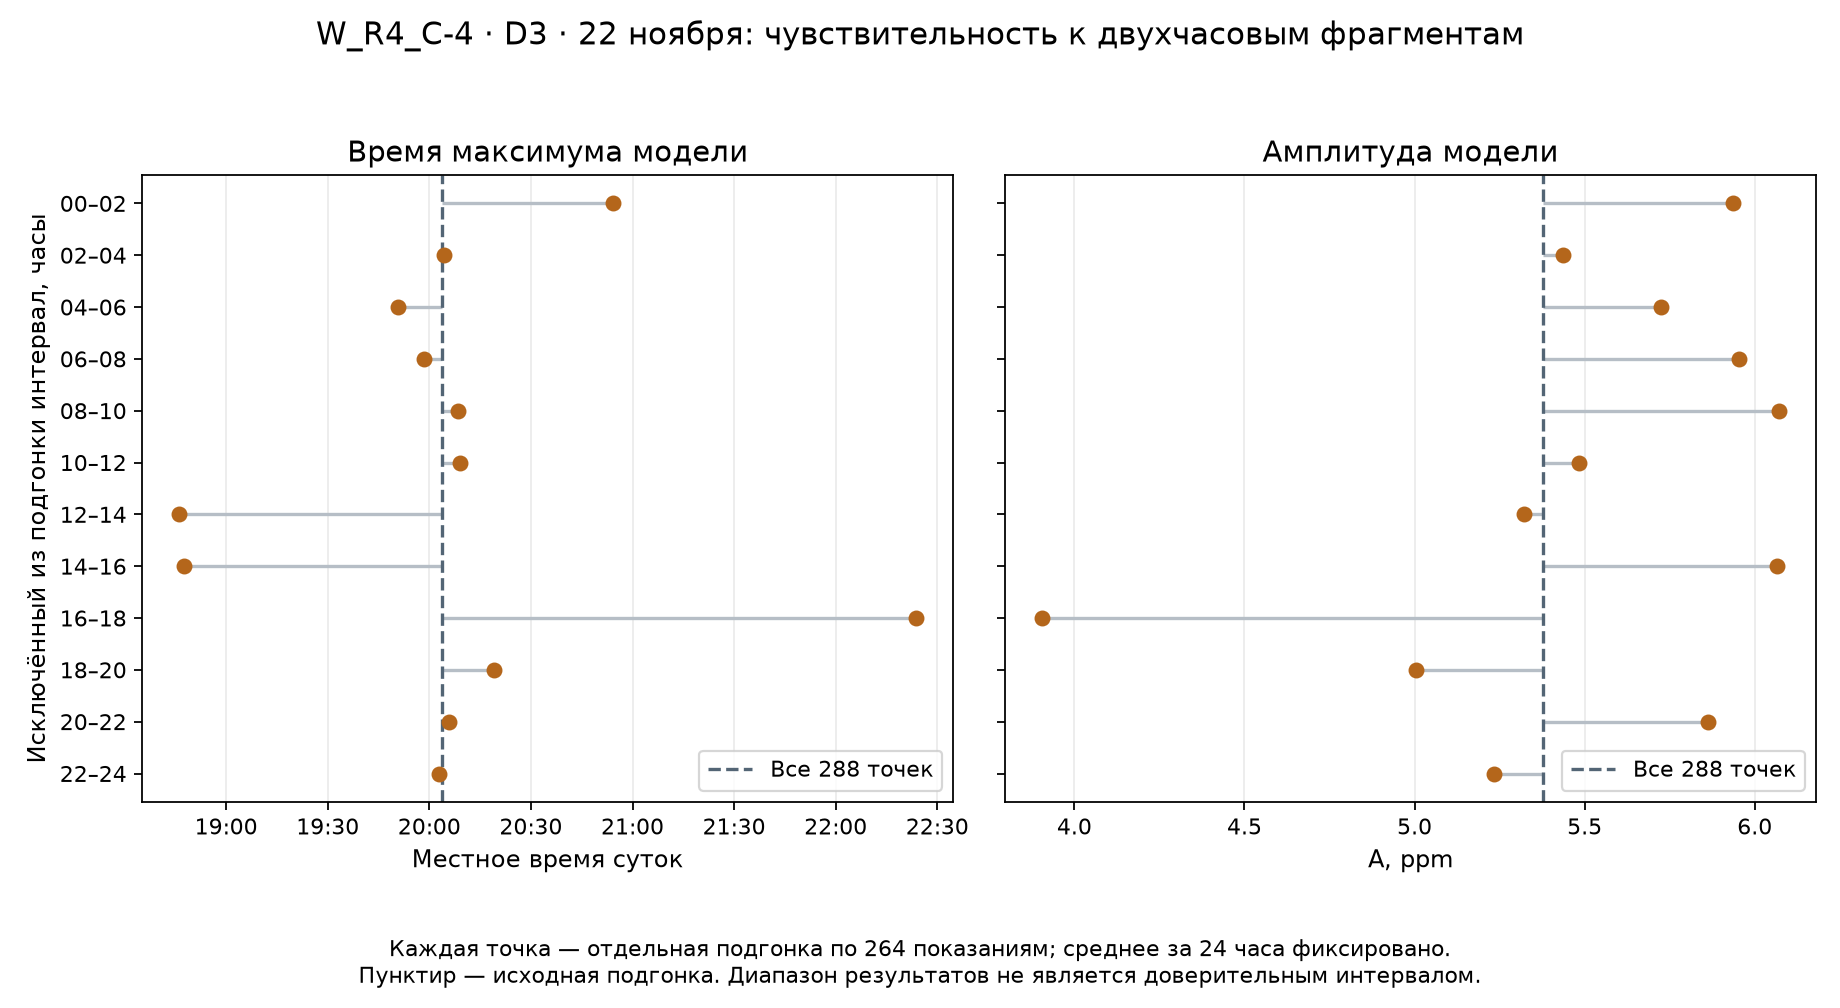

In [12]:
report.show("phase_sensitivity")

**Рисунок 2.11.** Каждая строка — исключённый двухчасовой интервал.
Слева — новый максимум, справа — амплитуда. Пунктир — подгонка по всем данным;
серые отрезки показывают изменение, а не погрешность.

| Подгонка | Максимум | Изменение, ч |
|---|---|---:|
| Все 288 точек | 20:04 | 0 |
| Без 12–14 часов | 18:46 | −1,29 |
| Без 16–18 часов | 22:24 | +2,33 |

**Получено:** среди 12 подгонок максимум меняется от **18:46 до 22:24**,
амплитуда — от **3,90 до 6,07 ppm**. Фаза D3 за этот день чувствительна
к включению отдельных частей суток. Исходный результат 20:04 сохраняю;
диапазон проверки не является доверительным интервалом.

**Проверка завершена.** Возвращаюсь к сравнению месяцев в основной главе.

[Вернуться к результату главы 2](../02_monthly_changes.ipynb) · [Метод и полная таблица](02_data_checks.md#d3-phase-sensitivity)


<a id="month-comparison"></a>

## 2.13. Сохранённое сравнение октября и ноября

Прежний результат: 22 октябрьских и 10 ноябрьских суток 2017 года. Ниже сохранены готовые рисунки, таблица и вывод, без нового расчёта.

[Метод и полные таблицы](02_data_checks.md#month-comparison).

Использую сохранённые измерения CO₂ датчиков **994 / 1010 / 1026**.
В ноябре исключил два залипания **12–14 и 26 ноября**; исходные записи сохранены.

**Примечание для I.G.:** имеются повторные временные метки, иногда с разными
концентрациями. Правило выбора записи пока не принято.


**Зачем:** сравнение должно опираться на явно выбранные измерения, а не смешивать
изменение сигнала с постоянными показаниями и повторными метками.

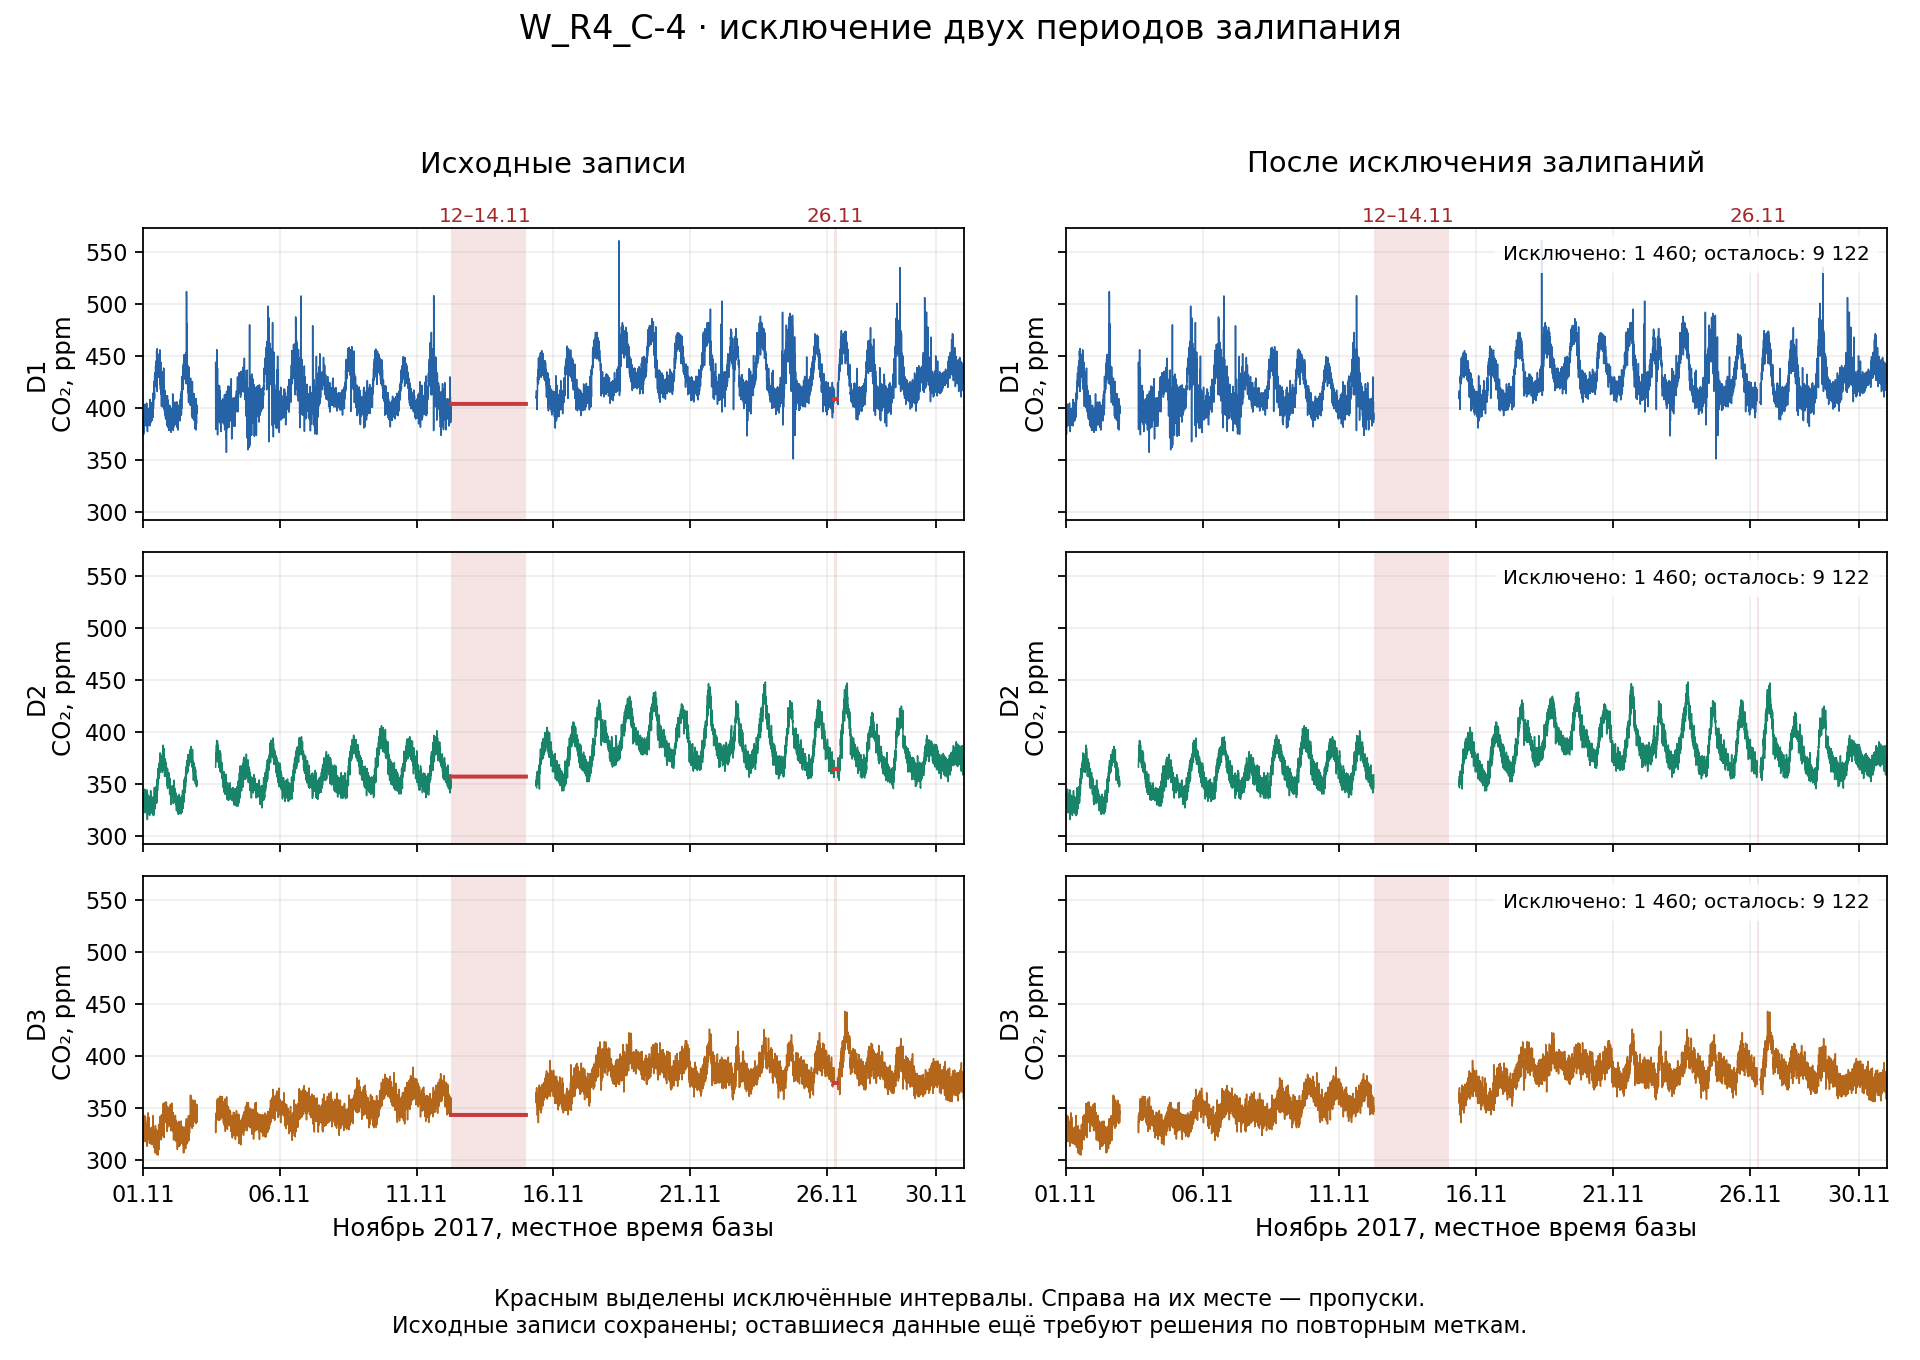

**Рисунок 2.3.** Слева — исходные записи ноября, справа — рабочие ряды
с пропусками вместо залипаний. Повторы не усредняю и не удаляю.

Проверил весь ноябрь по прежним правилам: из **30 суток** у **15** есть полное
окружающее окно ±12 часов. Из них **5** пока отложены из-за повторов в контексте
расчёта. Доступны **10 суток: 16–24 и 28 ноября**; для октября — **22 суток**.
Отбора по R² нет: слабый день D3 22 ноября сохранён.

[Даты и причины пропусков](02_data_checks.md#month-comparison) ·
[Подробная проверка данных](02_worked_examples.ipynb)


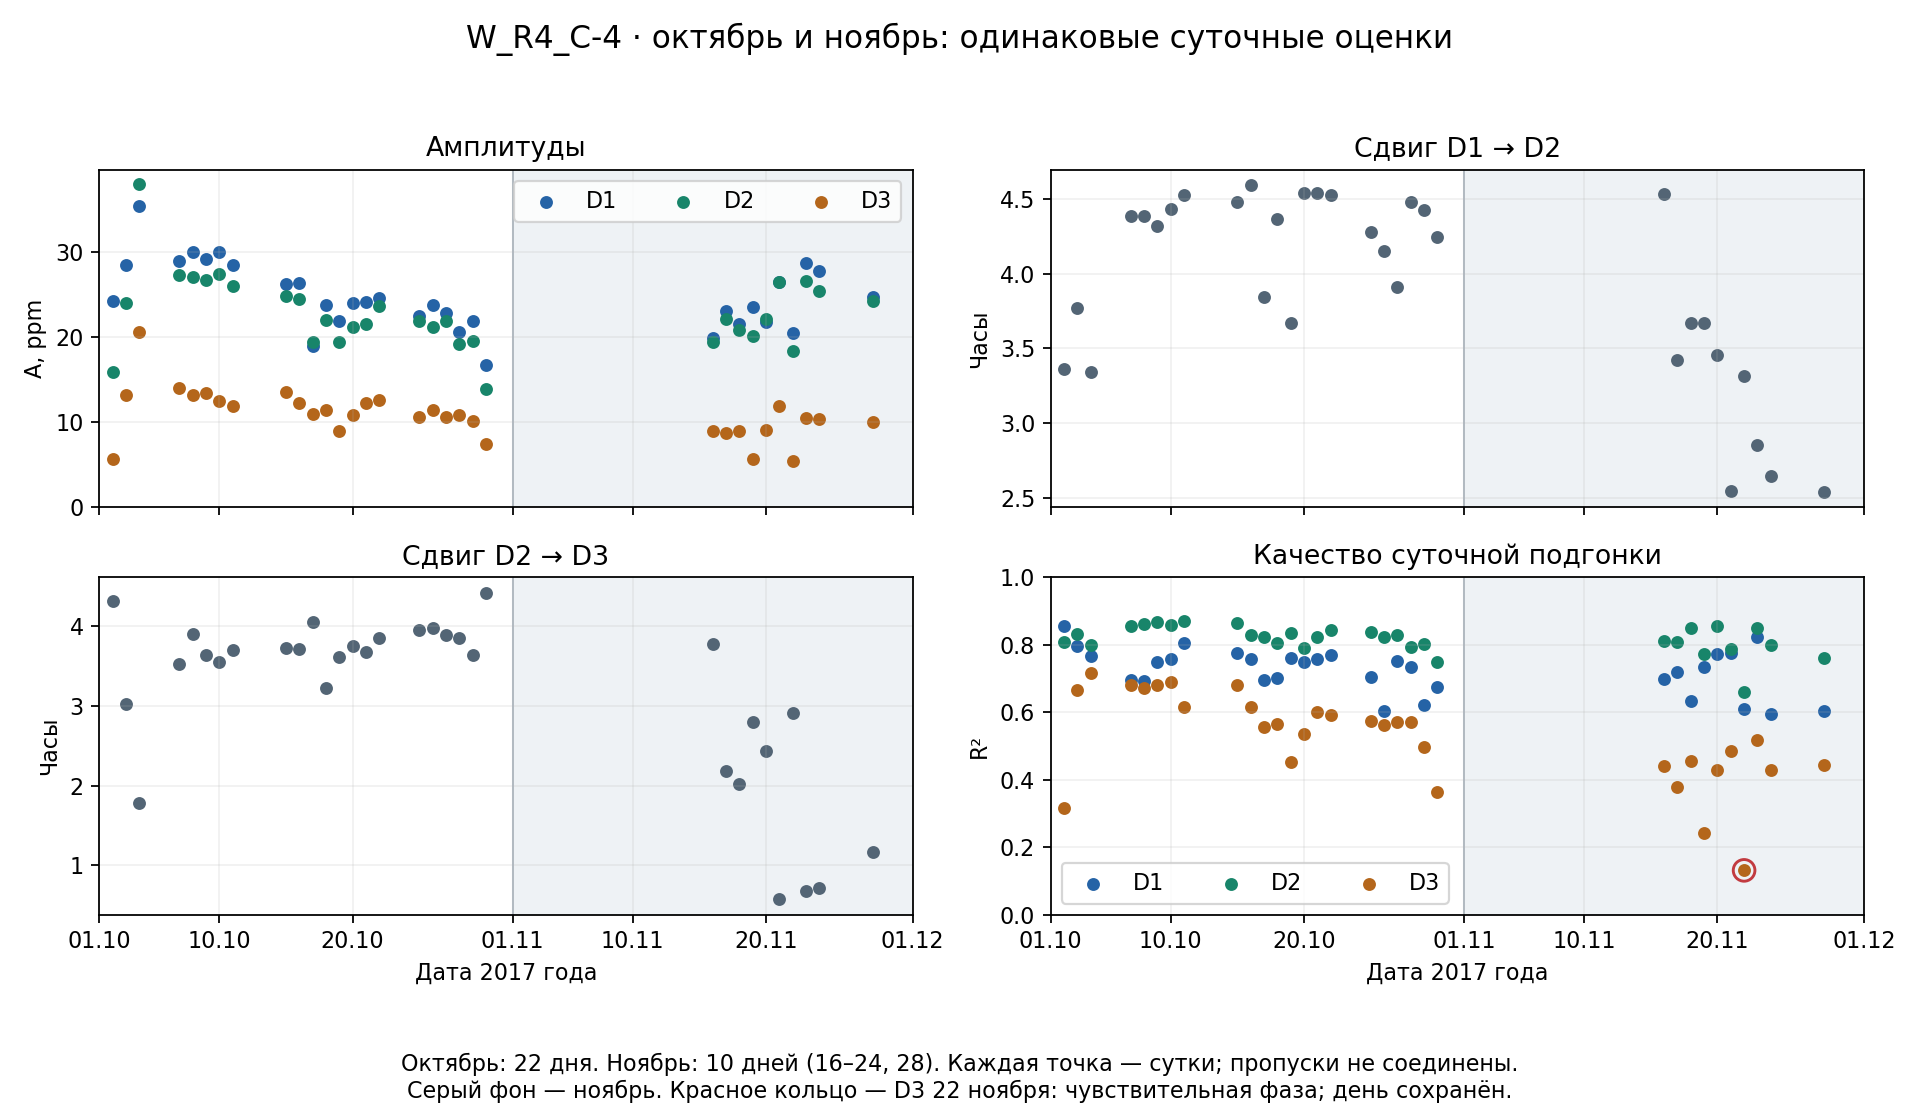

**Рисунок 2.4.** Каждая точка — сутки; серым выделен ноябрь. Пропуски не соединены.
Красное кольцо отмечает D3 22 ноября: его фаза чувствительна к частям ряда.

| Медиана дневных оценок | Октябрь, 22 дня | Ноябрь, 10 дней |
|---|---:|---:|
| Амплитуда D1, ppm | 24,18 | 23,29 |
| Амплитуда D2, ppm | 21,95 | 22,14 |
| Амплитуда D3, ppm | 11,68 | 9,05 |
| Сдвиг D1 → D2, ч | 4,37 | 3,37 |
| Сдвиг D2 → D3, ч | 3,72 | 2,10 |
| R² модели D3 | 0,58 | 0,44 |

**Вывод выполненного сравнения:** в доступных ноябрьских сутках медианные сдвиги меньше
примерно на **1,01 ч** и **1,62 ч**. Амплитуды D1/D2 по медианам близки,
у D3 амплитуда и качество описания ниже. Разности рассчитаны до округления.

Это предварительное сравнение доступных дней: покрытие месяцев неполное,
статистическая значимость и физическая причина различий не установлены.
Проверка D3 22 ноября показала чувствительность фазы; её
[подробный разбор](02_data_checks.md#d3-phase-sensitivity) завершён и вынесен из основной линии.

[Метод сравнения и все таблицы](02_data_checks.md#month-comparison)
